# Analiza zbioru danych MIT-BIH Arrhythmia Database

**Projekt:** Rozpoznawanie nieprawidłowych uderzeń serca na podstawie sygnału EKG  
**Przedmiot:** Akwizycja danych biomedycznych    
**Autorzy:** Ewa Kędziera, Jan Rapacz

---

Analiza ma pokazać:

- czym jest MIT-BIH Arrhythmia Database,
- jak wygląda surowy sygnał EKG,
- jak wczytać rekordy i adnotacje w Pythonie,
- jakie metadane zawierają rekordy,
- jakie typy uderzeń występują w bazie,
- jak bardzo niezbalansowane są klasy,
- jak można przejść od ciągłego sygnału EKG do próbek uczących,
- jakie decyzje projektowe są ważne przed trenowaniem modelu.

## 1. Informacje o bazie danych

**MIT-BIH Arrhythmia Database** to klasyczna publiczna baza sygnałów EKG, udostępniana przez PhysioNet. Zawiera **48 około półgodzinnych, dwukanałowych ambulatoryjnych zapisów EKG** pochodzących od **47 osób**. Sygnały zostały zdigitalizowane z częstotliwością **360 Hz**, z **11-bitową rozdzielczością** w zakresie około **10 mV**. Każdy rekord posiada adnotacje referencyjne przygotowane przez kardiologów.

Źródła:

- PhysioNet, MIT-BIH Arrhythmia Database: https://physionet.org/content/mitdb/1.0.0/
- MIT-BIH Arrhythmia Database Directory: https://physionet.org/physiobank/database/html/mitdbdir/intro.htm
- WFDB Python documentation: https://wfdb-python.readthedocs.io/
- WFDB annotation codes: https://physionet.org/physiotools/wpg/wpg_36.htm

### Najważniejsze cechy zbioru MIT-BIH Arrhythmia Database

MIT-BIH Arrhythmia Database jest jednym z najczęściej wykorzystywanych zbiorów danych do analizy sygnału EKG oraz badania zaburzeń rytmu serca. Jego istotną zaletą jest to, że zawiera rzeczywiste ambulatoryjne zapisy EKG wraz z eksperckimi adnotacjami uderzeń serca.

Z punktu widzenia analizy danych biomedycznych szczególnie ważne są następujące cechy tego zbioru:

1. zawiera rzeczywiste sygnały EKG pochodzące z zapisów ambulatoryjnych,
2. każdy rekord składa się z dwóch kanałów sygnału,
3. sygnały są opisane adnotacjami wskazującymi położenie i typ uderzeń serca,
4. w bazie występują różne typy uderzeń prawidłowych, arytmii oraz zaburzeń przewodzenia,
5. dane zawierają szumy i artefakty typowe dla praktycznej akwizycji sygnałów biomedycznych,
6. rekordy są zapisane w standardowym formacie WFDB, który można obsługiwać w Pythonie przy użyciu biblioteki `wfdb`.

## 2. Instalacja i import bibliotek

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb
from scipy import signal as scipy_signal

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True

DATASET_NAME = "mitdb"
OUTPUT_DIR = Path("outputs_mitdb_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

print("WFDB version:", wfdb.__version__)

WFDB version: 4.3.1


## 3. Lista rekordów MIT-BIH

MIT-BIH Arrhythmia Database zawiera 48 rekordów. Nazwy rekordów są jednocześnie identyfikatorami używanymi do pobierania danych z PhysioNet.

Kilka ważnych uwag:

- większość rekordów ma około 30 minut,
- każdy rekord ma dwa kanały EKG,
- rekordy `102`, `104`, `107` i `217` zawierają uderzenia stymulowane rozrusznikiem (`paced beats`), dlatego w wielu pracach są analizowane osobno albo wykluczane z podstawowej klasyfikacji zgodnej z AAMI/inter-patient split,
- część rekordów zawiera nietypowe, rzadsze arytmie - baza nie jest prostą losową próbą populacji.

In [2]:
RECORDS = [
    "100", "101", "102", "103", "104", "105", "106", "107", "108", "109",
    "111", "112", "113", "114", "115", "116", "117", "118", "119", "121",
    "122", "123", "124", "200", "201", "202", "203", "205", "207", "208",
    "209", "210", "212", "213", "214", "215", "217", "219", "220", "221",
    "222", "223", "228", "230", "231", "232", "233", "234"
]

PACED_RECORDS = ["102", "104", "107", "217"]

print("Liczba rekordów:", len(RECORDS))
print("Rekordy z paced beats:", PACED_RECORDS)

Liczba rekordów: 48
Rekordy z paced beats: ['102', '104', '107', '217']


## 4. Wczytanie przykładowego rekordu

Jako przykład wykorzystano rekord `100`. Biblioteka `wfdb` umożliwia wczytanie zarówno sygnału EKG, jak i powiązanych z nim adnotacji.

Najważniejsze elementy wykorzystywane podczas wczytywania danych:

- `rdrecord()` - wczytuje sygnał oraz metadane rekordu,
- `rdann()` - wczytuje adnotacje, np. adnotacje typu `atr`,
- `p_signal` - zawiera sygnał w jednostkach fizycznych, najczęściej w mV,
- `fs` - oznacza częstotliwość próbkowania sygnału.

In [3]:
record_id = "100"

record = wfdb.rdrecord(record_id, pn_dir=DATASET_NAME)
annotation = wfdb.rdann(record_id, "atr", pn_dir=DATASET_NAME)

signal_data = record.p_signal
fs = record.fs

print("Rekord:", record_id)
print("Kształt sygnału [liczba próbek, liczba kanałów]:", signal_data.shape)
print("Częstotliwość próbkowania [Hz]:", fs)
print("Długość zapisu [min]:", signal_data.shape[0] / fs / 60)
print("Nazwy kanałów:", record.sig_name)
print("Jednostki:", record.units)
print("Liczba adnotacji:", len(annotation.sample))
print("Pierwsze symbole adnotacji:", annotation.symbol[:20])
print("Pierwsze pozycje adnotacji [indeksy próbek]:", annotation.sample[:20])

Rekord: 100
Kształt sygnału [liczba próbek, liczba kanałów]: (650000, 2)
Częstotliwość próbkowania [Hz]: 360
Długość zapisu [min]: 30.092592592592595
Nazwy kanałów: ['MLII', 'V5']
Jednostki: ['mV', 'mV']
Liczba adnotacji: 2274
Pierwsze symbole adnotacji: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']
Pierwsze pozycje adnotacji [indeksy próbek]: [  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


### Interpretacja metadanych

Typowe wartości dla MIT-BIH:

- `fs = 360 Hz`, czyli 360 próbek na sekundę dla każdego kanału,
- dwa kanały EKG, najczęściej `MLII` i jeden z kanałów przedsercowych, np. `V1`, `V2`, `V5`,
- długość rekordu około 30 minut,
- adnotacje wskazują miejsca uderzeń oraz inne zdarzenia w sygnale, np. zmianę rytmu lub fragment z szumem.

### Odprowadzenia EKG w MIT-BIH

Kanały sygnału EKG odpowiadają różnym odprowadzeniom, czyli różnym sposobom rejestrowania aktywności elektrycznej serca.

`MLII` oznacza zmodyfikowane odprowadzenie kończynowe II. Jest to jedno z najczęściej wykorzystywanych odprowadzeń w analizie rytmu serca, ponieważ zwykle dobrze widoczne są w nim zespoły QRS, czyli fragmenty sygnału związane ze skurczem komór serca.

Odprowadzenia przedsercowe oznaczane są symbolami od `V1` do `V6`. W standardowym EKG elektrody przedsercowe umieszcza się na klatce piersiowej, dzięki czemu rejestrują one aktywność elektryczną serca z różnych kierunków. Z tego powodu ten sam cykl pracy serca może mieć nieco inny kształt w zależności od odprowadzenia.

| Odprowadzenia | Ogólna charakterystyka |
| ------------- | ---------------------- |
| `V1`, `V2` | odprowadzenia położone bardziej po prawej stronie klatki piersiowej; dobrze pokazują aktywność przegrody międzykomorowej i prawej części serca |
| `V3`, `V4` | odprowadzenia przednie; rejestrują aktywność z przedniej części serca |
| `V5`, `V6` | odprowadzenia boczne, położone bardziej po lewej stronie klatki piersiowej; dobrze pokazują aktywność lewej komory |

Różnice między odprowadzeniami są istotne, ponieważ kształt uderzenia serca może zależeć od kanału, z którego pochodzi sygnał.

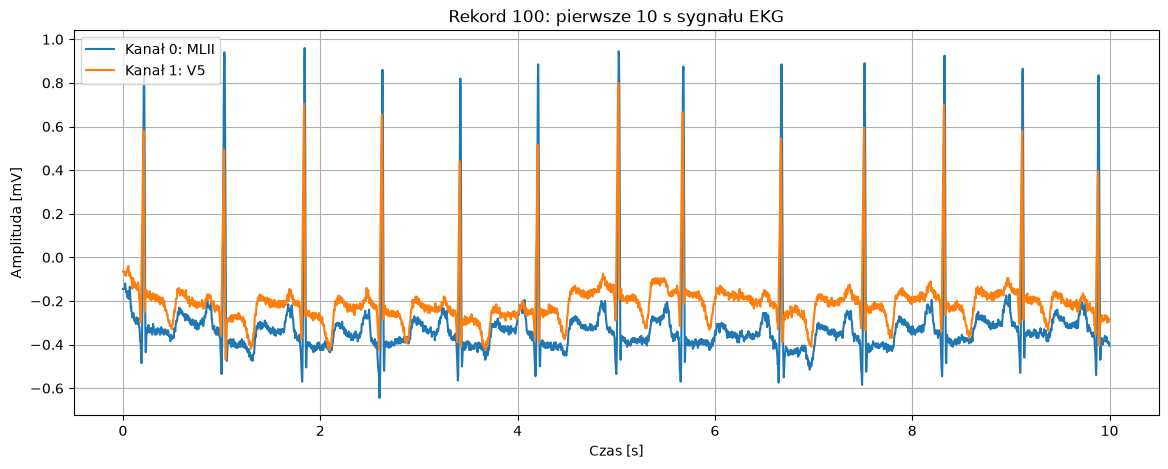

In [4]:
start_sec = 0
duration_sec = 10
start = int(start_sec * fs)
end = int((start_sec + duration_sec) * fs)
time_axis = np.arange(start, end) / fs

plt.figure(figsize=(14, 5))
for ch in range(signal_data.shape[1]):
    plt.plot(time_axis, signal_data[start:end, ch], label=f"Kanał {ch}: {record.sig_name[ch]}")

plt.title(f"Rekord {record_id}: pierwsze {duration_sec} s sygnału EKG")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda [mV]")
plt.legend()
plt.show()

## 5. Adnotacje uderzeń serca

Plik adnotacji `.atr` zawiera między innymi:

- indeks próbki, w której występuje adnotacja,
- symbol adnotacji, np. `N`, `V`, `A`, `L`, `R`,
- czasem dodatkową informację tekstową, np. o zmianie rytmu.

Nie każdy symbol oznacza pojedyncze uderzenie serca. Przykładowo `+` oznacza zmianę rytmu, a `~` może oznaczać zmianę jakości sygnału. Do klasyfikacji uderzeń trzeba więc wybrać tylko symbole odpowiadające uderzeniom.

In [5]:
def annotation_to_dataframe(annotation, fs, record_id):
    return pd.DataFrame({
        "record_id": record_id,
        "sample": annotation.sample,
        "time_sec": annotation.sample / fs,
        "symbol": annotation.symbol,
        "aux_note": annotation.aux_note if annotation.aux_note is not None else [None] * len(annotation.sample),
    })

ann_100 = annotation_to_dataframe(annotation, fs, record_id)
ann_100.head(20)

,record_id,sample,time_sec,symbol,aux_note
0,100,18,0.050000,+,(N 
1,100,77,0.213889,N,
2,100,370,1.027778,N,
3,100,662,1.838889,N,
4,100,946,2.627778,N,
5,100,1231,3.419444,N,
6,100,1515,4.208333,N,
7,100,1809,5.025000,N,
8,100,2044,5.677778,A,
9,100,2402,6.672222,N,


In [6]:
ann_100["symbol"].value_counts()

symbol
N    2239
A      33
+       1
V       1
Name: count, dtype: int64

### Najważniejsze symbole uderzeń

Poniższa tabela zawiera najważniejsze symbole, które zwykle są istotne przy klasyfikacji uderzeń w MIT-BIH.

In [7]:
SYMBOL_DESCRIPTION = {
    "N": "normal beat",
    "L": "left bundle branch block beat",
    "R": "right bundle branch block beat",
    "A": "atrial premature beat",
    "a": "aberrated atrial premature beat",
    "J": "nodal/junctional premature beat",
    "S": "supraventricular premature beat",
    "V": "premature ventricular contraction",
    "F": "fusion of ventricular and normal beat",
    "e": "atrial escape beat",
    "j": "nodal/junctional escape beat",
    "E": "ventricular escape beat",
    "/": "paced beat",
    "f": "fusion of paced and normal beat",
    "Q": "unclassifiable beat",
    "+": "rhythm change / rhythm annotation, not a beat sample",
    "~": "signal quality change / noise annotation",
}

symbol_table = pd.DataFrame(
    [{"symbol": k, "description": v} for k, v in SYMBOL_DESCRIPTION.items()]
)
symbol_table

,symbol,description
0,N,normal beat
1,L,left bundle branch block beat
2,R,right bundle branch block beat
3,A,atrial premature beat
4,a,aberrated atrial premature beat
5,J,nodal/junctional premature beat
6,S,supraventricular premature beat
7,V,premature ventricular contraction
8,F,fusion of ventricular and normal beat
9,e,atrial escape beat


## 6. Wizualizacja sygnału razem z adnotacjami

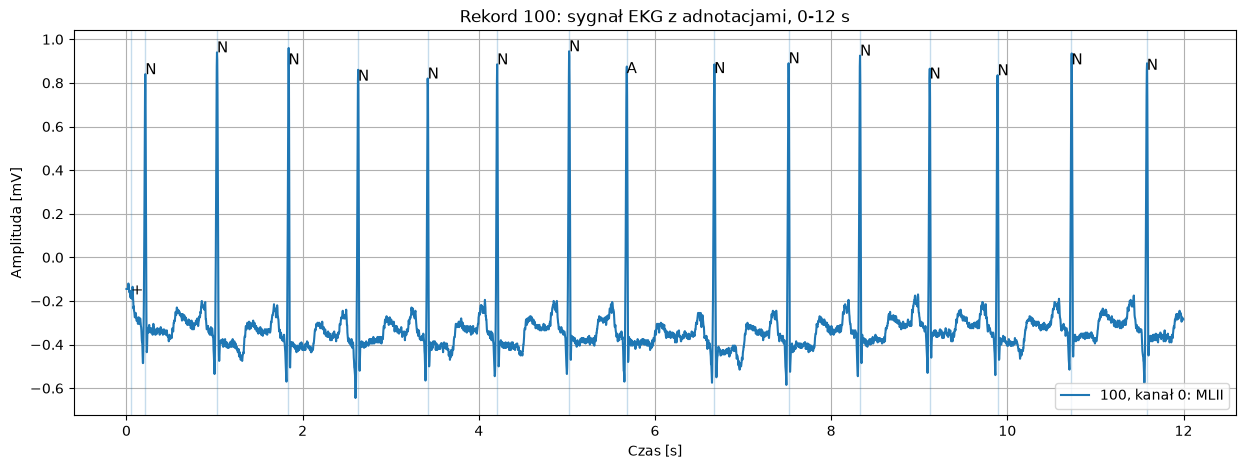

In [8]:
def plot_record_segment(record_id, start_sec=0, duration_sec=10, channel=0):
    rec = wfdb.rdrecord(record_id, pn_dir=DATASET_NAME)
    ann = wfdb.rdann(record_id, "atr", pn_dir=DATASET_NAME)
    fs = rec.fs

    start = int(start_sec * fs)
    end = int((start_sec + duration_sec) * fs)
    t = np.arange(start, end) / fs
    y = rec.p_signal[start:end, channel]

    ann_samples = np.asarray(ann.sample)
    ann_symbols = np.asarray(ann.symbol)
    mask = (ann_samples >= start) & (ann_samples < end)

    plt.figure(figsize=(15, 5))
    plt.plot(t, y, label=f"{record_id}, kanał {channel}: {rec.sig_name[channel]}")

    for sample, sym in zip(ann_samples[mask], ann_symbols[mask]):
        sample = int(sample)
        plt.axvline(sample / fs, alpha=0.25, linewidth=1)
        plt.text(sample / fs, rec.p_signal[sample, channel], sym, fontsize=11)

    plt.title(f"Rekord {record_id}: sygnał EKG z adnotacjami, {start_sec}-{start_sec + duration_sec} s")
    plt.xlabel("Czas [s]")
    plt.ylabel("Amplituda [mV]")
    plt.legend()
    plt.show()

plot_record_segment("100", start_sec=0, duration_sec=12, channel=0)

Wykres pokazuje, że adnotacje znajdują się w okolicy uderzeń serca, zwykle blisko zespołu QRS/R-peaku. To pozwala budować próbki do klasyfikacji, wycinając krótkie okna sygnału wokół danej adnotacji.

## 7. Analiza metadanych wszystkich rekordów

Poniżej zestawiono podstawowe informacje o wszystkich 48 rekordach dostępnych w MIT-BIH Arrhythmia Database. Dla każdego rekordu wczytano nagłówek oraz adnotacje, co pozwala określić:

- długość zapisu,
- liczbę kanałów sygnału,
- nazwy kanałów,
- liczbę adnotacji,
- rozkład symboli adnotacji.

In [9]:
def load_record_summary(record_id):
    header = wfdb.rdheader(record_id, pn_dir=DATASET_NAME)
    ann = wfdb.rdann(record_id, "atr", pn_dir=DATASET_NAME)
    fs = header.fs

    return {
        "record_id": record_id,
        "fs": fs,
        "n_sig": header.n_sig,
        "sig_len": header.sig_len,
        "duration_min": header.sig_len / fs / 60,
        "sig_names": ", ".join(header.sig_name),
        "units": ", ".join(header.units),
        "n_annotations": len(ann.sample),
        "comments": " | ".join(header.comments) if header.comments else "",
        "has_paced_beats_record": record_id in PACED_RECORDS,
    }

record_summaries = []
annotation_frames = []

for rid in RECORDS:
    summary = load_record_summary(rid)
    record_summaries.append(summary)

    header = wfdb.rdheader(rid, pn_dir=DATASET_NAME)
    ann = wfdb.rdann(rid, "atr", pn_dir=DATASET_NAME)
    annotation_frames.append(annotation_to_dataframe(ann, header.fs, rid))

records_df = pd.DataFrame(record_summaries)
annotations_df = pd.concat(annotation_frames, ignore_index=True)

records_df.to_csv(OUTPUT_DIR / "records_summary.csv", index=False)
annotations_df.to_csv(OUTPUT_DIR / "annotations_all.csv", index=False)

records_df.head()

,record_id,fs,n_sig,sig_len,duration_min,sig_names,units,n_annotations,comments,has_paced_beats_record
0,100,360,2,650000,30.092593,"MLII, V5","mV, mV",2274,"69 M 1085 1629 x1 | Aldomet, Inderal",False
1,101,360,2,650000,30.092593,"MLII, V1","mV, mV",1874,75 F 1011 654 x1 | Diapres,False
2,102,360,2,650000,30.092593,"V5, V2","mV, mV",2192,84 F 1525 167 x1 | Digoxin | The rhythm is pac...,True
3,103,360,2,650000,30.092593,"MLII, V2","mV, mV",2091,"-1 M 742 654 x1 | Diapres, Xyloprim",False
4,104,360,2,650000,30.092593,"V5, V2","mV, mV",2311,"66 F 1567 694 x1 | Digoxin, Pronestyl | The ra...",True


In [10]:
records_df[["duration_min", "n_annotations"]].describe().round(2)

,duration_min,n_annotations
count,48.00,48.00
mean,30.09,2346.81
std,0.00,451.69
min,30.09,1519.00
25%,30.09,2061.50
50%,30.09,2299.00
75%,30.09,2650.25
max,30.09,3400.00


In [11]:
records_df[["record_id", "fs", "n_sig", "duration_min", "sig_names", "n_annotations", "has_paced_beats_record"]]

,record_id,fs,n_sig,duration_min,sig_names,n_annotations,has_paced_beats_record
0,100,360,2,30.092593,"MLII, V5",2274,False
1,101,360,2,30.092593,"MLII, V1",1874,False
2,102,360,2,30.092593,"V5, V2",2192,True
3,103,360,2,30.092593,"MLII, V2",2091,False
4,104,360,2,30.092593,"V5, V2",2311,True
5,105,360,2,30.092593,"MLII, V1",2691,False
6,106,360,2,30.092593,"MLII, V1",2098,False
7,107,360,2,30.092593,"MLII, V1",2140,True
8,108,360,2,30.092593,"MLII, V1",1824,False
9,109,360,2,30.092593,"MLII, V1",2535,False


### Wnioski z metadanych

Typowo powinniśmy zobaczyć, że:

- wszystkie rekordy mają częstotliwość próbkowania 360 Hz,
- każdy rekord ma dwa kanały,
- długość rekordu wynosi około 30 minut,
- liczba adnotacji różni się między rekordami, co wynika m.in. z częstości rytmu serca, rodzaju rytmu oraz obecności arytmii.

## 8. Rozkład symboli adnotacji w całej bazie

In [12]:
symbol_counts = annotations_df["symbol"].value_counts().rename_axis("symbol").reset_index(name="count")
symbol_counts["description"] = symbol_counts["symbol"].map(SYMBOL_DESCRIPTION).fillna("other / less common annotation")
symbol_counts.head(30)

,symbol,count,description
0,N,75052,normal beat
1,L,8075,left bundle branch block beat
2,R,7259,right bundle branch block beat
3,V,7130,premature ventricular contraction
4,/,7028,paced beat
5,A,2546,atrial premature beat
6,+,1291,"rhythm change / rhythm annotation, not a beat ..."
7,f,982,fusion of paced and normal beat
8,F,803,fusion of ventricular and normal beat
9,~,616,signal quality change / noise annotation


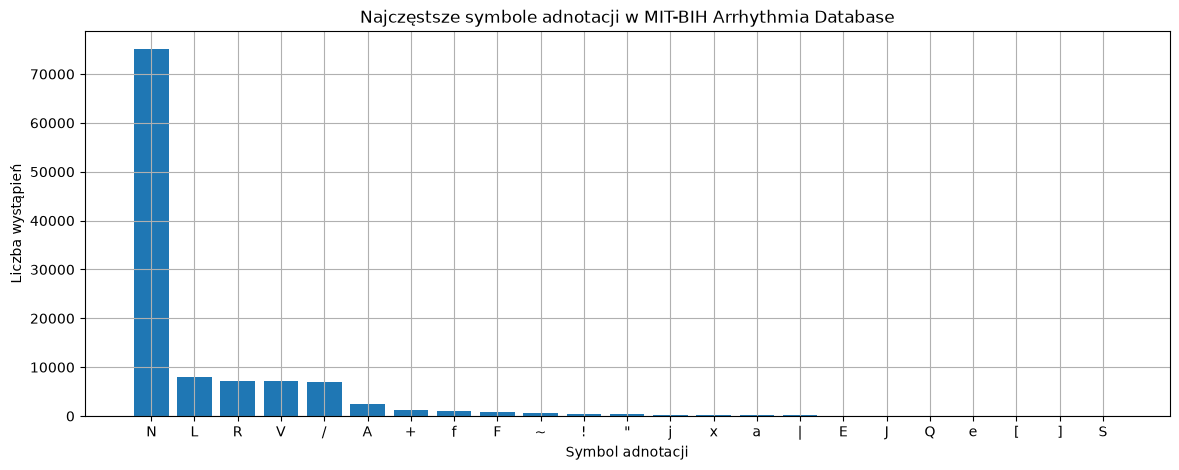

In [13]:
plt.figure(figsize=(14, 5))
plt.bar(symbol_counts["symbol"].astype(str).head(25), symbol_counts["count"].head(25))
plt.title("Najczęstsze symbole adnotacji w MIT-BIH Arrhythmia Database")
plt.xlabel("Symbol adnotacji")
plt.ylabel("Liczba wystąpień")
plt.show()

Główny problem klasyfikacji: **dominację klasy normalnej**. W praktyce model może osiągać wysoką accuracy nawet wtedy, gdy słabo wykrywa rzadsze uderzenia nieprawidłowe.

## 9. Grupowanie symboli do klas AAMI

W literaturze uderzenia z MIT-BIH często grupuje się zgodnie z nadklasami AAMI:

- `N` — uderzenia normalne i wybrane uderzenia przewodzeniowe/ucieczkowe,
- `S` — supraventricular ectopic beats,
- `V` — ventricular ectopic beats,
- `F` — fusion beats,
- `Q` — unknown / paced / unclassifiable.

W projekcie binarnym można dodatkowo uprościć problem do:

- `normal`,
- `abnormal`.

Uwaga: istnieją drobne różnice w mapowaniu między pracami. Poniżej zastosowano popularne mapowanie używane przy analizie MIT-BIH.

In [14]:
AAMI_GROUPS = {
    "N": ["N", "L", "R", "e", "j"],
    "S": ["A", "a", "J", "S"],
    "V": ["V", "E"],
    "F": ["F"],
    "Q": ["/", "f", "Q"],
}

SYMBOL_TO_AAMI = {
    symbol: group
    for group, symbols in AAMI_GROUPS.items()
    for symbol in symbols
}

def map_to_aami(symbol):
    return SYMBOL_TO_AAMI.get(symbol, "ignore")

def map_to_binary(symbol):
    aami = map_to_aami(symbol)
    if aami == "N":
        return "normal"
    elif aami in ["S", "V", "F", "Q"]:
        return "abnormal"
    else:
        return "ignore"

annotations_df["aami_class"] = annotations_df["symbol"].apply(map_to_aami)
annotations_df["binary_class"] = annotations_df["symbol"].apply(map_to_binary)

beats_df = annotations_df[annotations_df["aami_class"] != "ignore"].copy()

print("Liczba wszystkich adnotacji:", len(annotations_df))
print("Liczba adnotacji uderzeń użytych do klasyfikacji:", len(beats_df))
print("Liczba pominiętych adnotacji technicznych/rytmicznych:", len(annotations_df) - len(beats_df))

beats_df.head()

Liczba wszystkich adnotacji: 112647
Liczba adnotacji uderzeń użytych do klasyfikacji: 109494
Liczba pominiętych adnotacji technicznych/rytmicznych: 3153


,record_id,sample,time_sec,symbol,aux_note,aami_class,binary_class
1,100,77,0.213889,N,,N,normal
2,100,370,1.027778,N,,N,normal
3,100,662,1.838889,N,,N,normal
4,100,946,2.627778,N,,N,normal
5,100,1231,3.419444,N,,N,normal


In [15]:
aami_counts = beats_df["aami_class"].value_counts().reindex(["N", "S", "V", "F", "Q"]).fillna(0).astype(int)
aami_counts

aami_class
N    90631
S     2781
V     7236
F      803
Q     8043
Name: count, dtype: int64

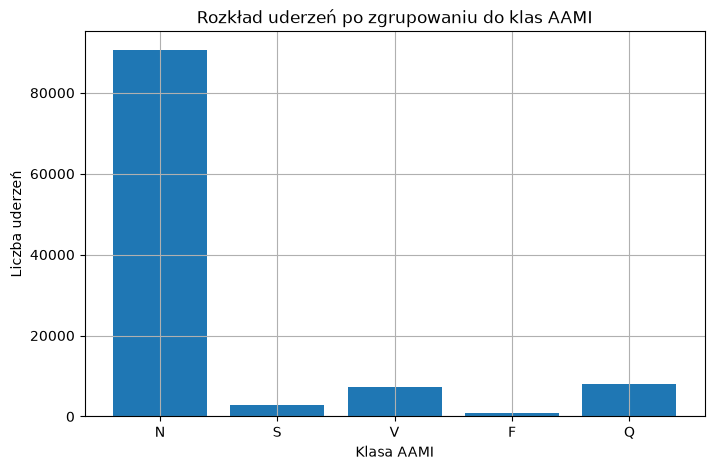

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(aami_counts.index, aami_counts.values)
plt.title("Rozkład uderzeń po zgrupowaniu do klas AAMI")
plt.xlabel("Klasa AAMI")
plt.ylabel("Liczba uderzeń")
plt.show()

In [17]:
binary_counts = beats_df["binary_class"].value_counts().reindex(["normal", "abnormal"]).fillna(0).astype(int)
binary_counts

binary_class
normal      90631
abnormal    18863
Name: count, dtype: int64

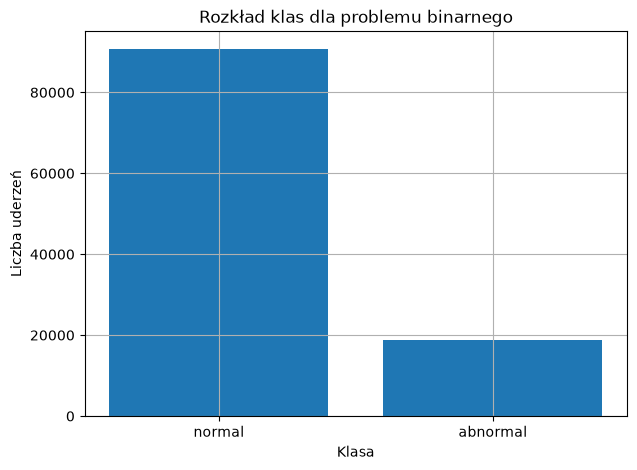

Udział klasy abnormal:
binary_class
normal      0.8277
abnormal    0.1723
Name: count, dtype: float64


In [18]:
plt.figure(figsize=(7, 5))
plt.bar(binary_counts.index, binary_counts.values)
plt.title("Rozkład klas dla problemu binarnego")
plt.xlabel("Klasa")
plt.ylabel("Liczba uderzeń")
plt.show()

print("Udział klasy abnormal:")
print((binary_counts / binary_counts.sum()).round(4))

### Wniosek: problem niezbalansowania klas

Zbiór jest silnie niezbalansowany. Większość uderzeń należy do klasy normalnej albo do szeroko rozumianej klasy `N` według AAMI. Dlatego w projekcie należy raportować nie tylko `accuracy`, ale też:

- `precision`,
- `recall` / `sensitivity`,
- `F1-score`,
- macierz pomyłek,
- osobne wyniki dla klasy nieprawidłowej.

Dla zastosowania medycznego szczególnie ważny jest **recall dla klasy nieprawidłowej**, ponieważ fałszywe przeoczenie arytmii jest zwykle poważniejszym problemem niż pojedynczy fałszywy alarm.

## 10. Rozkład klas w poszczególnych rekordach

Sprawdzimy, które rekordy zawierają dużo uderzeń nieprawidłowych. To ważne, ponieważ podział na train/test po pojedynczych uderzeniach mógłby powodować przeciek informacji między zbiorem treningowym i testowym.

In [19]:
record_class_counts = (
    beats_df
    .groupby(["record_id", "aami_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["N", "S", "V", "F", "Q"], fill_value=0)
)

record_class_counts.head()

aami_class,N,S,V,F,Q
record_id,,,,,
100,2239,33,1,0,0
101,1860,3,0,0,2
102,99,0,4,0,2084
103,2082,2,0,0,0
104,163,0,2,0,2064


In [20]:
record_class_counts["abnormal_total"] = record_class_counts[["S", "V", "F", "Q"]].sum(axis=1)
record_class_counts["all_beats"] = record_class_counts[["N", "S", "V", "F", "Q"]].sum(axis=1)
record_class_counts["abnormal_fraction"] = record_class_counts["abnormal_total"] / record_class_counts["all_beats"]

record_class_counts.sort_values("abnormal_fraction", ascending=False).head(15)

aami_class,N,S,V,F,Q,abnormal_total,all_beats,abnormal_fraction
record_id,,,,,,,,
107,0,0,59,0,2078,2137,2137,1.000000
102,99,0,4,0,2084,2088,2187,0.954733
104,163,0,2,0,2064,2066,2229,0.926873
217,244,0,162,0,1802,1964,2208,0.889493
232,398,1382,0,0,0,1382,1780,0.776404
208,1586,2,992,373,2,1369,2955,0.463283
200,1743,30,826,2,0,858,2601,0.329873
233,2230,7,831,11,0,849,3079,0.275739
106,1507,0,520,0,0,520,2027,0.256537


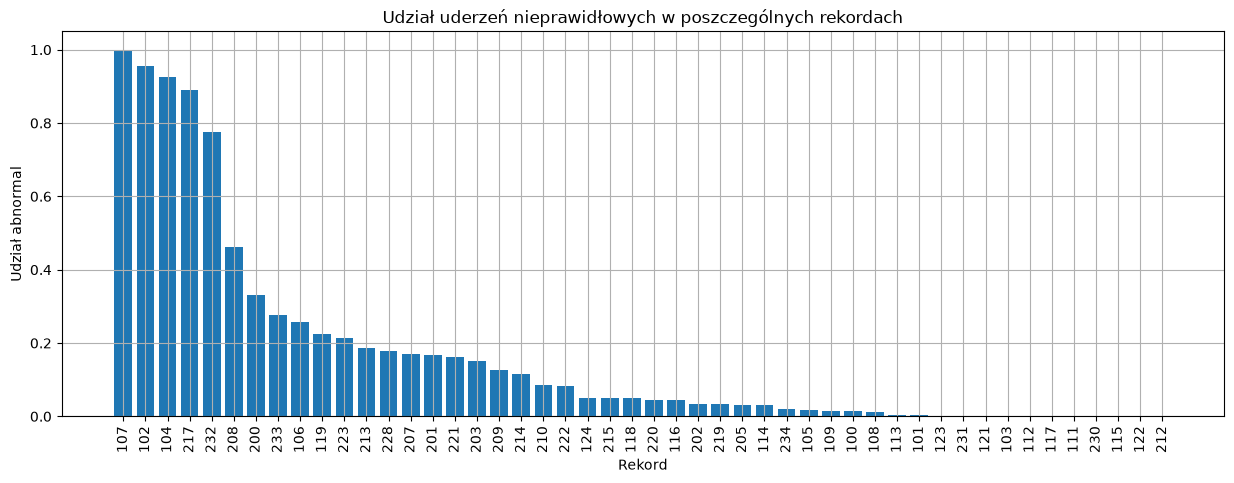

In [21]:
plot_df = record_class_counts.sort_values("abnormal_fraction", ascending=False)

plt.figure(figsize=(15, 5))
plt.bar(plot_df.index, plot_df["abnormal_fraction"])
plt.title("Udział uderzeń nieprawidłowych w poszczególnych rekordach")
plt.xlabel("Rekord")
plt.ylabel("Udział abnormal")
plt.xticks(rotation=90)
plt.show()

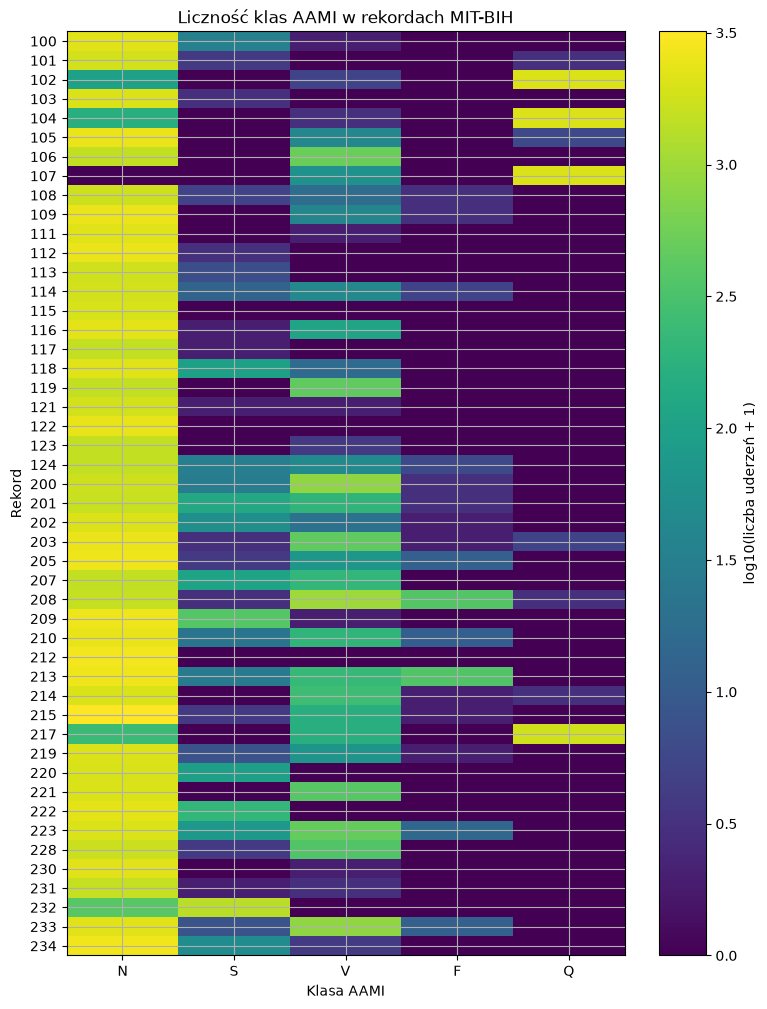

In [22]:
heatmap_df = record_class_counts[["N", "S", "V", "F", "Q"]].copy()
heatmap_values = np.log10(heatmap_df.values + 1)

plt.figure(figsize=(9, 12))
plt.imshow(heatmap_values, aspect="auto")
plt.colorbar(label="log10(liczba uderzeń + 1)")
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns)
plt.title("Liczność klas AAMI w rekordach MIT-BIH")
plt.xlabel("Klasa AAMI")
plt.ylabel("Rekord")
plt.show()

### Wniosek metodologiczny

Niektóre typy uderzeń są skoncentrowane w wybranych rekordach. Dlatego losowy podział pojedynczych uderzeń na train/test może sztucznie zawyżyć wyniki, bo model będzie widział bardzo podobne uderzenia tego samego pacjenta w treningu i teście.

Lepsze podejście projektowe:

- dzielić dane po rekordach/pacjentach,
- jasno opisać, które rekordy trafiły do treningu i testu,
- unikać przecieku informacji między rekordami.

## 11. Analiza odstępów RR

Odstęp RR to czas między kolejnymi uderzeniami serca. Jest ważny, bo arytmie często wpływają nie tylko na kształt uderzenia, ale też na rytm, czyli odstępy między uderzeniami.

W prostym projekcie można użyć wyłącznie morfologii uderzenia, ale w lepszym podejściu można dodać cechy rytmiczne, np.:

- poprzedni odstęp RR,
- następny odstęp RR,
- lokalną średnią RR,
- stosunek bieżącego RR do średniego RR.

In [23]:
def add_rr_intervals(df, records_df):
    parts = []
    fs_by_record = records_df.set_index("record_id")["fs"].to_dict()

    for rid, group in df.sort_values(["record_id", "sample"]).groupby("record_id"):
        g = group.copy()
        fs = fs_by_record[rid]
        g["rr_prev_sec"] = g["sample"].diff() / fs
        g["rr_next_sec"] = g["sample"].diff(-1).abs() / fs
        parts.append(g)

    return pd.concat(parts, ignore_index=True)

beats_rr_df = add_rr_intervals(beats_df, records_df)
beats_rr_df[["record_id", "sample", "symbol", "aami_class", "rr_prev_sec", "rr_next_sec"]].head(10)

,record_id,sample,symbol,aami_class,rr_prev_sec,rr_next_sec
0,100,77,N,N,NaN,0.813889
1,100,370,N,N,0.813889,0.811111
2,100,662,N,N,0.811111,0.788889
3,100,946,N,N,0.788889,0.791667
4,100,1231,N,N,0.791667,0.788889
5,100,1515,N,N,0.788889,0.816667
6,100,1809,N,N,0.816667,0.652778
7,100,2044,A,S,0.652778,0.994444
8,100,2402,N,N,0.994444,0.844444
9,100,2706,N,N,0.844444,0.811111


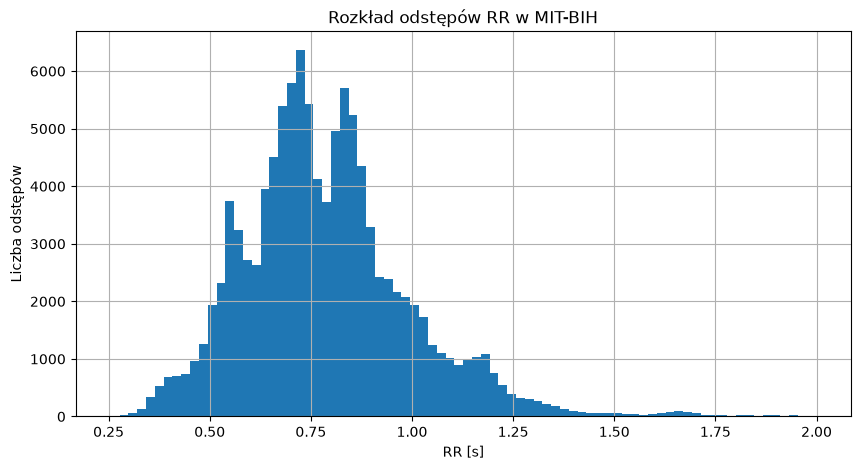

Podstawowe statystyki RR [s]:
count    109304.000000
mean          0.787670
std           0.209040
min           0.255556
25%           0.655556
50%           0.763889
75%           0.888889
max           1.997222
Name: rr_prev_sec, dtype: float64


In [24]:
rr = beats_rr_df["rr_prev_sec"].dropna()
rr = rr[(rr > 0.25) & (rr < 2.0)]

plt.figure(figsize=(10, 5))
plt.hist(rr, bins=80)
plt.title("Rozkład odstępów RR w MIT-BIH")
plt.xlabel("RR [s]")
plt.ylabel("Liczba odstępów")
plt.show()

print("Podstawowe statystyki RR [s]:")
print(rr.describe())

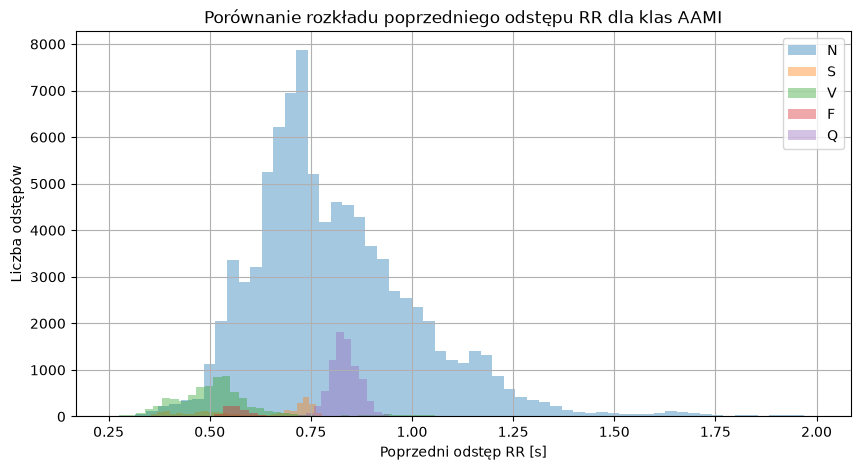

In [25]:
plt.figure(figsize=(10, 5))
for cls in ["N", "S", "V", "F", "Q"]:
    values = beats_rr_df.loc[beats_rr_df["aami_class"] == cls, "rr_prev_sec"].dropna()
    values = values[(values > 0.25) & (values < 2.0)]
    if len(values) > 0:
        plt.hist(values, bins=60, alpha=0.4, label=cls)

plt.title("Porównanie rozkładu poprzedniego odstępu RR dla klas AAMI")
plt.xlabel("Poprzedni odstęp RR [s]")
plt.ylabel("Liczba odstępów")
plt.legend()
plt.show()

## 12. Przykład filtracji sygnału EKG

Sygnał EKG może zawierać:

- dryft linii bazowej,
- zakłócenia mięśniowe,
- zakłócenia sieciowe,
- artefakty ruchowe.

W podstawowej analizie można zastosować filtr pasmowoprzepustowy, np. około 0.5–40 Hz. To nie jest jedyna poprawna konfiguracja, ale jest dobrym punktem startowym do wizualizacji i klasyfikacji morfologii uderzeń.

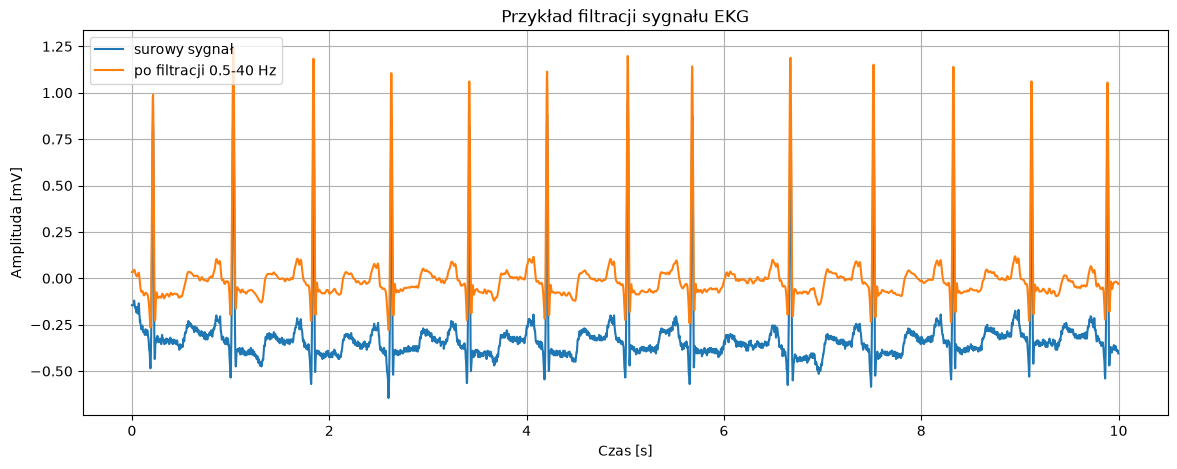

In [26]:
def bandpass_filter_ecg(x, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = scipy_signal.butter(order, [low, high], btype="band")  # projektowanie filtru Butterwortha
    return scipy_signal.filtfilt(b, a, x)  # zastosowanie filtru do sygnału; b, a - współczynniki filtru cyfrowego

channel = 0
start_sec = 0
end_sec = 10
start = int(start_sec * fs)
end = int(end_sec * fs)

raw_fragment = signal_data[start:end, channel]
filtered_fragment = bandpass_filter_ecg(raw_fragment, fs)
t = np.arange(start, end) / fs

plt.figure(figsize=(14, 5))
plt.plot(t, raw_fragment, label="surowy sygnał")
plt.plot(t, filtered_fragment, label="po filtracji 0.5-40 Hz")
plt.title("Przykład filtracji sygnału EKG")
plt.xlabel("Czas [s]")
plt.ylabel("Amplituda [mV]")
plt.legend()
plt.show()

## 13. Segmentacja uderzeń: od ciągłego sygnału do próbek uczących

Do klasyfikacji pojedynczych uderzeń można wycinać krótkie okna wokół adnotacji. Przykładowo:

- 0.25 s przed adnotacją,
- 0.45 s po adnotacji.

Dla `fs = 360 Hz` daje to około 252 próbki na uderzenie.

Ważna decyzja projektowa: czy używać tylko jednego kanału, czy obu kanałów. Na początek najprościej użyć jednego kanału, np. pierwszego kanału rekordu.

In [27]:
def extract_beat_windows(record_id, channel=0, pre_sec=0.25, post_sec=0.45, use_filter=True):
    # Wycięcie okien wokół adnotowanych uderzeń dla jednego rekordu.
    # Zwraca: X [n_beats, window_len], y, meta_df.
    rec = wfdb.rdrecord(record_id, pn_dir=DATASET_NAME)
    ann = wfdb.rdann(record_id, "atr", pn_dir=DATASET_NAME)
    fs = rec.fs

    x = rec.p_signal[:, channel]
    if use_filter:
        x = bandpass_filter_ecg(x, fs)

    pre = int(pre_sec * fs)
    post = int(post_sec * fs)

    windows = []
    labels = []
    meta = []

    for sample, symbol in zip(ann.sample, ann.symbol):
        aami = map_to_aami(symbol)
        binary = map_to_binary(symbol)

        if aami == "ignore":
            continue

        left = sample - pre
        right = sample + post
        if left < 0 or right > len(x):
            continue

        window = x[left:right]
        windows.append(window)
        labels.append(binary)
        meta.append({
            "record_id": record_id,
            "sample": int(sample),
            "symbol": symbol,
            "aami_class": aami,
            "binary_class": binary,
            "channel": channel,
            "pre_sec": pre_sec,
            "post_sec": post_sec,
        })

    X = np.asarray(windows)
    y = np.asarray(labels)
    meta_df = pd.DataFrame(meta)
    return X, y, meta_df

X100, y100, meta100 = extract_beat_windows("100", channel=0, pre_sec=0.25, post_sec=0.45)

print("X100 shape:", X100.shape)
print("y100 shape:", y100.shape)
print(meta100["binary_class"].value_counts())
meta100.head()

X100 shape: (2271, 252)
y100 shape: (2271,)
binary_class
normal      2237
abnormal      34
Name: count, dtype: int64


,record_id,sample,symbol,aami_class,binary_class,channel,pre_sec,post_sec
0,100,370,N,N,normal,0,0.25,0.45
1,100,662,N,N,normal,0,0.25,0.45
2,100,946,N,N,normal,0,0.25,0.45
3,100,1231,N,N,normal,0,0.25,0.45
4,100,1515,N,N,normal,0,0.25,0.45


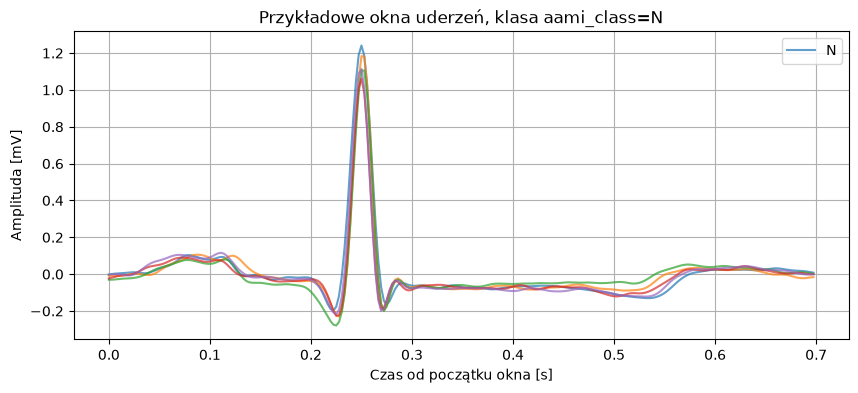

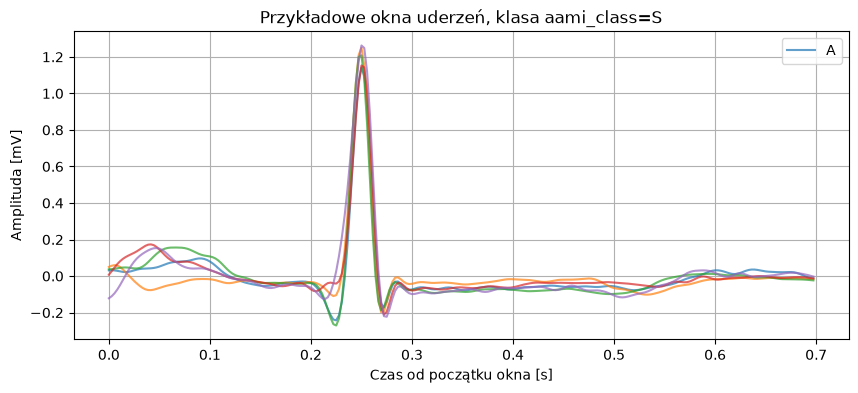

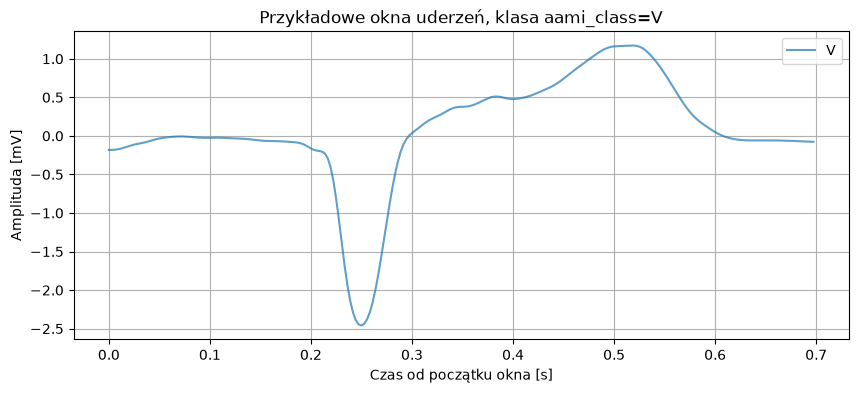

In [28]:
def plot_example_beats(X, meta_df, n_examples=5, class_column="aami_class"):
    classes = meta_df[class_column].unique()
    fs = 360
    time = np.arange(X.shape[1]) / fs

    for cls in classes:
        idx = meta_df.index[meta_df[class_column] == cls].tolist()[:n_examples]
        if not idx:
            continue

        plt.figure(figsize=(10, 4))
        for i in idx:
            label = f"{meta_df.loc[i, 'symbol']}" if i == idx[0] else None
            plt.plot(time, X[i], alpha=0.7, label=label)
        plt.title(f"Przykładowe okna uderzeń, klasa {class_column}={cls}")
        plt.xlabel("Czas od początku okna [s]")
        plt.ylabel("Amplituda [mV]")
        plt.legend()
        plt.show()

plot_example_beats(X100, meta100, n_examples=5, class_column="aami_class")

### Co daje segmentacja?

Po segmentacji mamy klasyczny zbiór danych do uczenia maszynowego:

- `X` - macierz próbek, gdzie każdy wiersz to jedno uderzenie,
- `y` - etykieta, np. `normal` / `abnormal`,
- `meta_df` - metadane: rekord, pozycja próbki, oryginalny symbol, klasa AAMI.

To jest naturalny punkt wyjścia do dalszego modelowania w Pythonie.

## 14. Podział danych: ważna pułapka projektowa

Dla MIT-BIH bardzo ważne jest, żeby nie robić prostego losowego podziału pojedynczych uderzeń, np. `train_test_split(X, y)`, bez kontroli rekordów. Taki podział może spowodować, że uderzenia tego samego pacjenta trafią jednocześnie do treningu i testu.

Lepsze podejścia:

1. **podział po rekordach**, czyli rekordy treningowe i testowe są rozłączne,
2. znany podział **DS1/DS2** stosowany w wielu pracach inter-patient,
3. walidacja grupowa, np. `GroupKFold`, gdzie grupą jest `record_id`.

Poniżej znajduje się popularny podział DS1/DS2. W wielu pracach wyklucza się rekordy `102`, `104`, `107`, `217`, ponieważ zawierają paced beats.

In [29]:
DS1_TRAIN = [
    "101", "106", "108", "109", "112", "114", "115", "116", "118", "119", "122", "124",
    "201", "203", "205", "207", "208", "209", "215", "220", "223", "230"
]

DS2_TEST = [
    "100", "103", "105", "111", "113", "117", "121", "123", "200", "202", "210", "212",
    "213", "214", "219", "221", "222", "228", "231", "232", "233", "234"
]

excluded = sorted(set(RECORDS) - set(DS1_TRAIN) - set(DS2_TEST))
print("DS1 train records:", len(DS1_TRAIN))
print("DS2 test records:", len(DS2_TEST))
print("Excluded records:", excluded)

DS1 train records: 22
DS2 test records: 22
Excluded records: ['102', '104', '107', '217']


In [30]:
def split_name(record_id):
    if record_id in DS1_TRAIN:
        return "DS1_train"
    if record_id in DS2_TEST:
        return "DS2_test"
    return "excluded"

beats_df["split"] = beats_df["record_id"].apply(split_name)

split_counts = (
    beats_df
    .groupby(["split", "aami_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["N", "S", "V", "F", "Q"], fill_value=0)
)

split_counts

aami_class,N,S,V,F,Q
split,,,,,
DS1_train,45866,944,3788,415,8
DS2_test,44259,1837,3221,388,7
excluded,506,0,227,0,8028


In [31]:
split_binary_counts = (
    beats_df
    .groupby(["split", "binary_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["normal", "abnormal"], fill_value=0)
)

split_binary_counts

binary_class,normal,abnormal
split,,
DS1_train,45866,5155
DS2_test,44259,5453
excluded,506,8255


## 15. Eksport przygotowanych tabel

Poniższe pliki zostały zapisane do katalogu `outputs_mitdb_analysis`:

- `records_summary.csv` - metadane rekordów,
- `annotations_all.csv` - wszystkie adnotacje z rekordów.

In [32]:
print("Zapisane pliki:")
for path in OUTPUT_DIR.glob("*.csv"):
    print("-", path)

Zapisane pliki:
- outputs_mitdb_analysis\annotations_all.csv
- outputs_mitdb_analysis\records_summary.csv


## Podsumowanie

MIT-BIH Arrhythmia Database jest bardzo dobrym zbiorem do projektu o wykrywaniu nieprawidłowych uderzeń serca, ponieważ zawiera rzeczywiste sygnały EKG, eksperckie adnotacje i wiele typów zaburzeń rytmu. Zbiór jest niewielki, dobrze udokumentowany i wygodny do użycia w Pythonie.

Najważniejsze ograniczenia:

- silne niezbalansowanie klas,
- niektóre typy arytmii występują rzadko,
- część rekordów zawiera uderzenia stymulowane rozrusznikiem,
- losowy podział uderzeń może prowadzić do przecieku informacji,
- wyniki należy oceniać metrykami czułymi na klasę mniejszościową.